### Importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Loading dataset

In [ ]:
df=pd.DataFrame(pd.read_csv("data/sales_data.csv"))

### Shape & Size of dataset

In [ ]:
print(f"Shape of the dataset : {df.shape}\n")
print(f"No.of rows/entries in the dataset : {df.shape[0]}")

### Information about the dataset

In [ ]:
col=df.columns
print(f"Columns in the dataset : \n{pd.Series(col)}\n")
print(f"Data types of the columns : \n{df.dtypes}\n")

### Unique entries in REGION

In [ ]:
uni_region=df["Region"].unique()
print(f"Unique regions in the dataset : \n{pd.Series(uni_region)}")

### Unique entries in PRODUCT

In [ ]:
uni_prod=df['Product'].unique()
print(f"Unique products in the dataset : \n{pd.Series(uni_prod)}")

### Region-wise quantity analysis

In [ ]:
print(f"Average amount of quantity sold overall: {df['Quantity'].mean()}")

In [ ]:
region_wise_sum=df.groupby("Region")["Quantity"].sum()
plt.figure(figsize=(8,8))
plt.pie(region_wise_sum, labels=region_wise_sum.index, autopct='%1.1f%%')
plt.title('Distribution of Quantity Sold Region-Wise')
plt.show()

In [ ]:
print(df.groupby("Region")["Total_Sales"].sum())
# print(df["Quantity"].mean())

In [ ]:
plt.figure(figsize=(8,8))
plt.bar(region_wise_sum.index, region_wise_sum.values)
plt.xlabel('Region')
plt.ylabel('Total Quantity Sold')
plt.title('Bar Chart of Total Quantity Sold Region-Wise')
plt.show()

In [ ]:
plt.figure(figsize=(8,8))
plt.plot(region_wise_sum.index, region_wise_sum.values)
plt.xlabel('Region')
plt.ylabel('Total Quantity Sold')
plt.title('Line chart of Total Quantity Sold Region-Wise')
plt.show()

### Region-wise Sales analysis

In [ ]:
print(f"Total sales amount overall : ₹{df['Total_Sales'].sum()}")

In [ ]:
print(f"Average sales amount overall: ₹{df['Total_Sales'].mean()}\n")

In [ ]:
sales_regionwise=df.groupby('Region')['Total_Sales'].sum()
print(f"Total region-wise sales amount :\n{sales_regionwise}")

In [ ]:
avg_sales_regionwise=df.groupby('Region')['Total_Sales'].mean()
print(f"Average region-wise sales amount :\n{avg_sales_regionwise}")

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(sales_regionwise, labels=sales_regionwise.index, autopct='%1.1f%%')
plt.title('Distribution of Sale-Amount Region-Wise')
plt.show()

In [ ]:
plt.figure(figsize=(8,8))
plt.bar(sales_regionwise.index, sales_regionwise.values)
plt.title('Bar Chart of Total Sales revenue Region-Wise')
plt.xlabel('Region')
plt.ylabel('Total Sales revenue (Lakhs)')
plt.show()

In [ ]:
plt.figure(figsize=(8,8))
plt.plot(sales_regionwise.index, sales_regionwise.values)
plt.title('Line Chart of Total Sales revenue Region-Wise')
plt.xlabel('Region')
plt.ylabel('Total Sales revenue (Lakhs)')
plt.show()

### Product-wise Quantity analysis

In [ ]:
prod_quantity=df.groupby('Product')['Quantity'].sum()
print(f"Total quantity sold product-wise :\n{prod_quantity}")

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(prod_quantity.values, labels=prod_quantity.index, autopct='%1.1f%%')
plt.title('Distribution of quantity sold Product-wise')
plt.show()

### Product-wise Sales analysis

#### Overall sale

In [ ]:
prod_sale=df.groupby('Product')['Total_Sales'].sum()
print(f"Total sales amount product-wise :\n{prod_sale}")

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(prod_sale.values, labels=prod_sale.index, autopct='%1.1f%%')
plt.title('Distribution of Total-Sale revenue product-wise')
plt.show()

### Grouping by Date

### Monthly sale analysis

#### Converting date data type

In [ ]:
df['Date']=pd.to_datetime(df['Date'])
print(f"Data type of 'Date' column: {df['Date'].dtype}")

#### Month-wise overall sales analysis

In [ ]:
monthly_sale=df.groupby(df['Date'].dt.to_period('M'))['Total_Sales'].sum()
monthly_sale.index=monthly_sale.index.strftime('%B %Y')

print(f"Monthly sales amount :\n{monthly_sale}")

In [ ]:
plt.figure(figsize=(8,8))
plt.pie(monthly_sale, labels=monthly_sale.index, autopct='%1.1f%%')
plt.title('Distribution of monthly revenue')
plt.show()

#### Month-wise average sales analysis

In [ ]:
avg_monthly_sale=df.groupby(df['Date'].dt.to_period('M'))['Total_Sales'].mean()
avg_monthly_sale.index=avg_monthly_sale.index.strftime('%B %Y')

print(f"Average monthly sales amount :\n{avg_monthly_sale}")

In [ ]:
plt.figure(figsize=(8,8))
plt.plot(monthly_sale.index, monthly_sale.values)
plt.title('Line Chart of monthly revenue')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.ylabel('Revenue (Lakhs)')
plt.show()

### Products' trends

#### LAPTOP trends

In [36]:
laptop_data = df[df["Product"]=="Laptop"]
print(f"Data of sales of Laptop :\n{laptop_data.head()}")

Data of sales of Laptop :
        Date Product  Quantity  Price Customer_ID Region  Total_Sales
4 2024-01-05  Laptop         8  39835     CUST005  North       318680
5 2024-01-06  Laptop         7  40420     CUST006  South       282940
6 2024-01-07  Laptop         9  40430     CUST007  South       363870
7 2024-01-08  Laptop         7   7262     CUST008   West        50834
9 2024-01-10  Laptop         4  45023     CUST010   West       180092


In [ ]:
laptop_data=laptop_data.groupby(laptop_data['Date'].dt.to_period('M'))['Total_Sales'].sum()
laptop_data.index = laptop_data.index.strftime("%B %Y")

In [48]:
print(laptop_data)

Date
January 2024     1981281
February 2024     285064
March 2024       1522863
April 2024        100002
Name: Total_Sales, dtype: int64


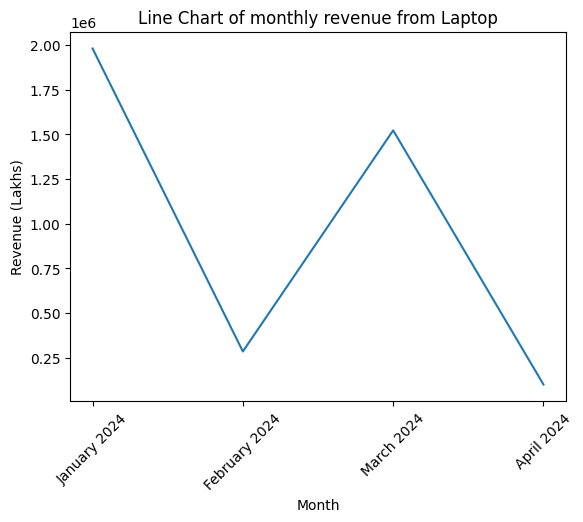

In [50]:
plt.plot(laptop_data.index, laptop_data.values)
plt.title('Line Chart of monthly revenue from Laptop')
plt.xlabel('Month')
plt.ylabel('Revenue (Lakhs)')
plt.xticks(rotation=45)
plt.show()

#### Phone trends

In [54]:
Phone_data = df[df["Product"]=="Phone"]
print(f"Data of sales of Phone :\n{Phone_data.head()}")

Phone_data=Phone_data.groupby(Phone_data['Date'].dt.to_period('M'))['Total_Sales'].sum()
Phone_data.index = Phone_data.index.strftime("%B %Y")

print(Phone_data)

Data of sales of Phone :
         Date Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01   Phone         7  37300     CUST001   East       261100
2  2024-01-03   Phone         2  21746     CUST003   West        43492
11 2024-01-12   Phone         2  13233     CUST012   West        26466
12 2024-01-13   Phone         8  20655     CUST013   East       165240
15 2024-01-16   Phone         9  41548     CUST016  South       373932
Date
January 2024      937670
February 2024     838792
March 2024       1082932
Name: Total_Sales, dtype: int64


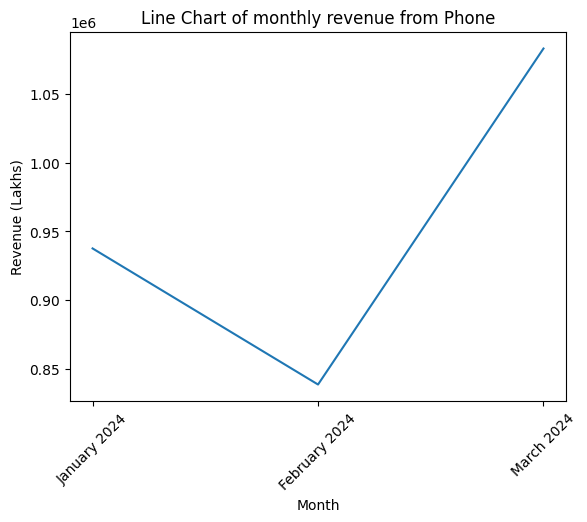

In [55]:
plt.plot(Phone_data.index, Phone_data.values)
plt.title('Line Chart of monthly revenue from Phone')
plt.xlabel('Month')
plt.ylabel('Revenue (Lakhs)')
plt.xticks(rotation=45)
plt.show()

#### Headphone trends

In [58]:
Headphones_data = df[df["Product"]=="Headphones"]
print(f"Data of sales of Headphones :\n{Headphones_data.head()}")

Headphones_data=Headphones_data.groupby(Headphones_data['Date'].dt.to_period('M'))['Total_Sales'].sum()
Headphones_data.index = Headphones_data.index.strftime("%B %Y")

print(Headphones_data)

Data of sales of Headphones :
         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
13 2024-01-14  Headphones         4   4195     CUST014   East        16780
14 2024-01-15  Headphones         2  34447     CUST015   West        68894
23 2024-01-24  Headphones         1  17838     CUST024   West        17838
Date
January 2024     241498
February 2024     73396
March 2024       687734
April 2024       381405
Name: Total_Sales, dtype: int64


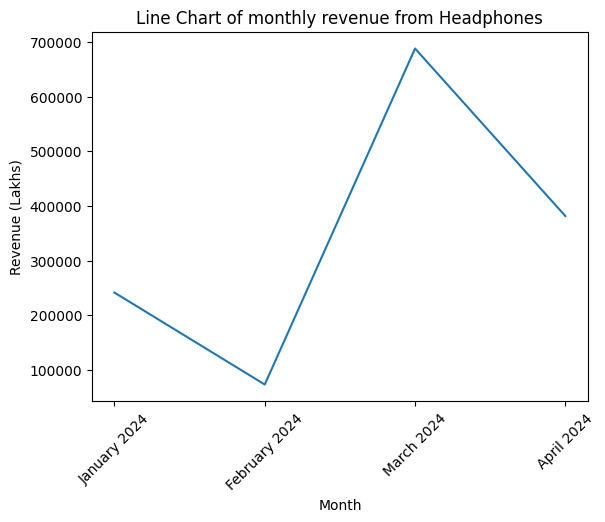

In [59]:
plt.plot(Headphones_data.index, Headphones_data.values)
plt.title('Line Chart of monthly revenue from Headphones')
plt.xlabel('Month')
plt.ylabel('Revenue (Lakhs)')
plt.xticks(rotation=45)
plt.show()

#### Tablet trends

In [60]:
tablet_data = df[df["Product"]=="Tablet"]
print(f"Data of sales of Tablet :\n{tablet_data.head()}")

tablet_data=tablet_data.groupby(tablet_data['Date'].dt.to_period('M'))['Total_Sales'].sum()
tablet_data.index = tablet_data.index.strftime("%B %Y")

print(tablet_data)

Data of sales of Tablet :
         Date Product  Quantity  Price Customer_ID Region  Total_Sales
8  2024-01-09  Tablet         3  32791     CUST009  North        98373
17 2024-01-18  Tablet         4  19322     CUST018  North        77288
18 2024-01-19  Tablet         1  44045     CUST019   West        44045
21 2024-01-22  Tablet         2   6713     CUST022   West        13426
26 2024-01-27  Tablet         1  38298     CUST027  North        38298
Date
January 2024     892413
February 2024    686477
March 2024       714106
April 2024       591344
Name: Total_Sales, dtype: int64


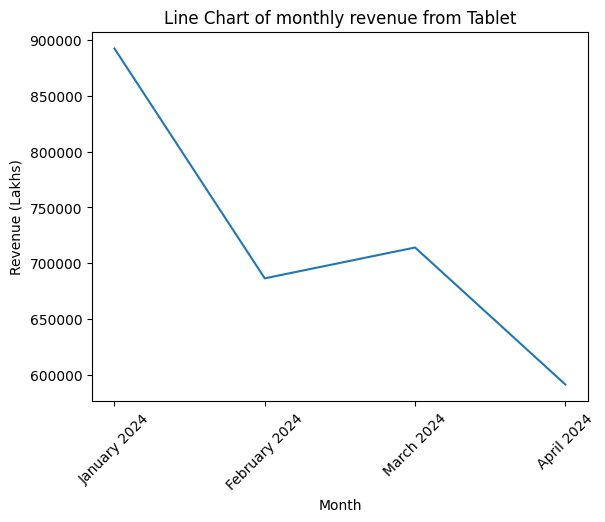

In [61]:
plt.plot(tablet_data.index, tablet_data.values)
plt.title('Line Chart of monthly revenue from Tablet')
plt.xlabel('Month')
plt.ylabel('Revenue (Lakhs)')
plt.xticks(rotation=45)
plt.show()

#### Monitor trends 

In [62]:
monitor_data = df[df["Product"]=="Monitor"]
print(f"Data of sales of Monitor :\n{monitor_data.head()}")

monitor_data=monitor_data.groupby(monitor_data['Date'].dt.to_period('M'))['Total_Sales'].sum()
monitor_data.index = monitor_data.index.strftime("%B %Y")

print(monitor_data)

Data of sales of Monitor :
         Date  Product  Quantity  Price Customer_ID Region  Total_Sales
10 2024-01-11  Monitor         8   6160     CUST011   West        49280
24 2024-01-25  Monitor         2   9191     CUST025   West        18382
37 2024-02-07  Monitor         8  19256     CUST038   East       154048
38 2024-02-08  Monitor         1  39924     CUST039  South        39924
40 2024-02-10  Monitor         1  20083     CUST041   West        20083
Date
January 2024      67662
February 2024    772321
March 2024       477371
April 2024        30717
Name: Total_Sales, dtype: int64


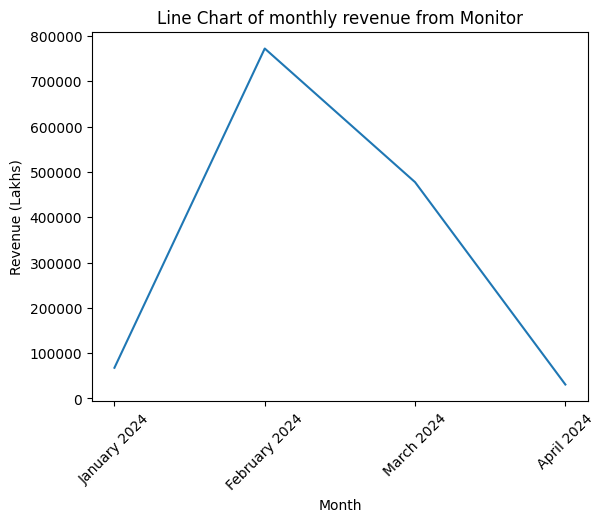

In [63]:
plt.plot(monitor_data.index, monitor_data.values)
plt.title('Line Chart of monthly revenue from Monitor')
plt.xlabel('Month')
plt.ylabel('Revenue (Lakhs)')
plt.xticks(rotation=45)
plt.show()

#### combined trends

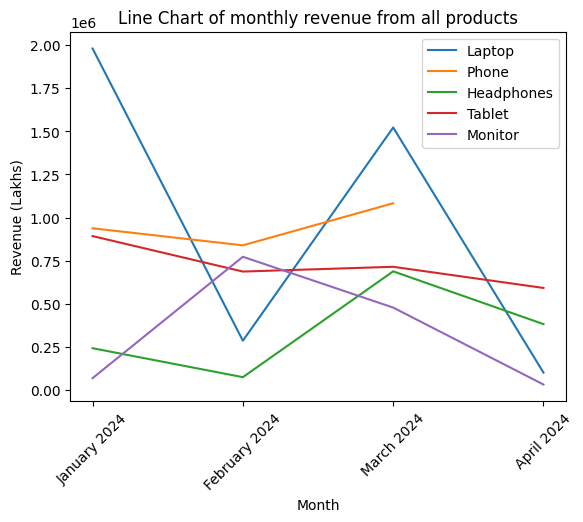

In [70]:
plt.plot(laptop_data.index, laptop_data.values, label='Laptop')
plt.plot(Phone_data.index, Phone_data.values, label='Phone')
plt.plot(Headphones_data.index, Headphones_data.values, label='Headphones')
plt.plot(tablet_data.index, tablet_data.values, label='Tablet')
plt.plot(monitor_data.index, monitor_data.values, label='Monitor')
# plt.plot(monthly_sale.index, monthly_sale.values, label='Overall')

plt.title('Line Chart of monthly revenue from all products')
plt.xlabel('Month')
plt.ylabel('Revenue (Lakhs)')
plt.xticks(rotation=45)
plt.legend()
plt.show()